# Экспериментальное исследование алгоритмов для регулярных запросов

## Постановки задач

В данной работе исследуется производительность решения задачи достижимости с регулярными ограничениями (Regular Path Querying, RPQ) на ориентированных графах двух алгоритмов на основе достижимости:
 - между всеми парами вершин,
 - для заданного множества стартовых вершин.

Исследование направлено на ответы на следующие вопросы:
- Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач?
- Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?


## Описание исследуемых решений

В работе рассматриваются две реализации RPQ:

1) [Tensor-based RPQ](../project/adjacency_matrix_fa.py#L167):

   Алгоритм основан на тензорном (кронекеровом) произведении двух конечных автоматов:
   - автомата, построенного на основе входного графа;
   - автомата, соответствующего регулярному выражению запроса.

   После построения объединённой матрицы вычисляется её транзитивное замыкание - путём последовательного возведения матрицы в степень до сходимости. Полученная матрица отражает достижимость всех пар состояний, удовлетворяющих регулярному ограничению. На её основе выделяются искомые пары вершин исходного графа.

2) [MS BFS-based RPQ](../project/bfs_rpq.py)

   Данный алгоритм реализует многократный обход в ширину (Multiple-Source BFS), выполненный в терминах линейной алгебры. В отличие от тензорного подхода, здесь не строится полный декартов автомат. Вместо этого осуществляется итеративное синхронное продвижение по графу и автомату запроса.

   Для каждой стартовой вершины формируется матрица состояния (`front`), отражающая текущее множество пар (вершина графа, состояние автомата, соответствующего регулярному выражению запроса). Эти матрицы объединяются в структуру `fronts`, а совокупность уже посещённых пар хранится в `reachable`. На каждой итерации выполняется шаг распространения:

   `new_front` = $ G^{T} * $ `front` $ * ~ R $,

   где:
    - $ G^{𝑇} $ - транспонированная матрица переходов графа,
    - $ R $ - матрица переходов автомата запроса.

   Результат отражает новые достижимые состояния, соответствующие допустимым по регулярному выражению. Алгоритм продолжается до тех пор, пока fronts не станут пустыми (т.е. не появятся новые достижимые состояния). После завершения все пары (стартовая вершина, достижимая вершина) извлекаются из матриц reachable.

Обе реализации используют класс [AdjacencyMatrixFA](../project/adjacency_matrix_fa.py), который представляет конечный автомат в виде набора разреженных матриц переходов (по одному на каждый символ алфавита).


## Описание набора данных для экспериментов

### Графы
В экспериментах использовались следующие графы из [`CFPQ_Data`](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/index.html):
 - [`skos`](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/data/skos.html#skos)
 - [`biomedical`](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/data/biomedical.html#biomedical)
 - [`people`](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/data/people.html#people)

Данные графы были выбраны потому, что они достаточно компактны, чтобы уместиться в оперативной памяти, используемого оборудования и при этом анализ их производительности на нормальном количестве запусков занимает приемлемое время. Графы `biomedical` (341 вершина, 459 рёбер) и `people` (337 вершин, 640 рёбер) имеют сопоставимое число вершин, но различаются по плотности связности. Это позволяет оценить влияние количества ненулевых элементов в разреженных матрицах на производительность алгоритмов.

### Запросы
Для каждого графа были сформированы четыре регулярных выражения, использующие все основные конструкции регулярных языков (замыкание, конкатенация, альтернатива):
 - `(m1 | m2)* m3`
 - `(m3 | m4)+ m1*`
 - `m1 m2 m3 (m4 | m1)*`
 - `m3 (m2 | m4)* m1+`

где m1, m2, m3, m4 наиболее часто встречающиеся метки в графах

### Количество стартовых вершин
Стартовые вершины генерировались с помощью функции [generate_multiple_source_percent](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/reference/graphs/generated/cfpq_data.graphs.utils.multiple_source_utils.html#cfpq_data.graphs.utils.multiple_source_utils.generate_multiple_source_percent). Для каждого графа тестировались множества размером `5%`, `10%`, `20%`, `30%`, `45%`, `60%`, `80%` и `100%` от общего числа вершин. Генерация выполнялась с фиксированным seed, что гарантирует воспроизводимость экспериментов. Выбор именно процентного подхода (а не фиксированного числа вершин) позволяет корректно сравнивать графы разного размера и выявлять порог, при котором алгоритм для всех пар становится предпочтительнее.

## Оборудование

 - **Процессор:** Intel Core i7-11370H с зафиксированной частотой 3.3 GHz (`sudo cpupower frequency-set --min 3300MHz --max 3300MHz`)
   - **Кэш L1:** 80 КБ на ядро
   - **Кэш L2:** 1.25 МБ на ядро
   - **Общий кэш L3:** 12 МБ
 - **ОЗУ:** 16ГБ
 - **ОС:** Linux Kubuntu 24.04
 - **Версия Python:** 3.12.5
 - **Настройки производительности:** для минимизации влияния динамического изменения частоты процессора спользовался режим `performance` (`sudo cpupower frequency-set -g performance`), сторонние процессы были минимизированы

## Описание эксперимента
 - Для ответа на первый вопрос были выбраны четыре формата разреженных матриц из библиотеки [SciPy](https://docs.scipy.org/doc/scipy/reference/sparse.html):
   - [csr_array](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csr_array.html#scipy.sparse.csr_array) - Compressed Sparse Row array
   - [csc_array](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csc_array.html#scipy.sparse.csc_array) - Compressed Sparse Column array
   - [dok_array](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.dok_array.html#scipy.sparse.dok_array) - Dictionary Of Keys based sparse array
   - [lil_array](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.lil_array.html#scipy.sparse.lil_array) - Row-based List of Lists sparse array

    Для каждой комбинации типа разреженной матрицы, графа и регулярного выражения оба алгоритма выполнялись по 20 раз. В качестве итоговой оценки производительности использовалось среднее время выполнения, а также был рассчитан 95% доверительный интервал.

 - Для ответа на второй вопрос для каждого регулярного выражения и каждого графа проводились измерения времени выполнения обоих алгоритмов при различных размерах стартового множества. Для каждой конфигурации выполнялось 20 запусков, и на их основе (аналогично ответу на 1 вопрос) вычислялись среднее время выполнения и 95% доверительный интервал.

Стоит отметить, что при создании экземпляра AdjacencyMatrixFA используется промежуточный формат `lil_array` для инициализации матриц. Только после заполнения всех переходов матрицы конвертируются в целевой (пареданный) тип. Этот подход использован, так как `lil_array` эффективен при динамическом изменении структуры матрицы, что критично на этапе построения автомата из графа. В официальной документации SciPy явно [рекомендуется](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.lil_array.html#scipy.sparse.lil_array) (в разделе `Notes` в пункте `Intended Usage`) использовать `lil_array` именно для этапа построения, а затем конвертировать в `csr`/`csc` для последующих операций. Это помогает исследовать имеено наиболее подхоядщее представление для операций в алгоритмах.

## Подготовка к проведению эксперимента

### Импорты, отключение логов и ворнингов

In [3]:
# To run in vs code
import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import time
import networkx
import numpy
import matplotlib.pyplot as plt
import cfpq_data
import pandas as pd

from IPython.display import display, Markdown
from collections import Counter
from typing import Set, Dict, List
from scipy import stats
from scipy.sparse import csr_array, csc_array, dok_array, lil_array
from scipy.sparse import SparseEfficiencyWarning
from project.bfs_rpq import ms_bfs_based_rpq
from project.adjacency_matrix_fa import tensor_based_rpq, MatrixType

import logging
import warnings

logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)

import sources directory


### Глобальные переменны

In [4]:
EXPERIMENT_GRAPHS: List[str] = [
    "skos",
    "biomedical",
    "people",
]

REGEX_TEMPLATES: List[str] = [
    "(m1 | m2)* m3",
    "(m3 | m4)+ m1*",
    "m1 m2 m3 (m4 | m1)*",
    "m3 (m2 | m4)* m1+",
]

MATRIX_TYPES: Dict[str, MatrixType] = {
    "csr": csr_array,
    "csc": csc_array,
    "lil": lil_array,
    "dok": dok_array,
}

START_NODES_PERCENTAGES: List[int] = [5, 10, 20, 30, 45, 60, 80, 100]
NUMBER_OF_LAUNCHES: int = 20

### Вспомагательные функции
Были реализованы следующие вспомогательные функции:
 - `build_regex_from_labels()` - формирует набор из регулярных выражений на основе четырёх наиболее частотных меток рёбер графа
 - `get_start_nodes()` - генерирует множество стартовых вершин заданного размера
 - `analyze_execution_data()` - выполняет анализ серии замеров времени выполнения
 - `round_results()` - округляет среднее время и доверительный интервал до значащих цифр, соответствующих точности измерения

In [4]:
def build_regex_from_labels(labels: List[str]) -> List[str]:
    m1, m2, m3, m4 = [str(label) for label in labels[:4]]

    return [
        f"({m1}|{m2})* {m3}",
        f"({m3}|{m4})+ {m1}*",
        f"{m1} {m2} {m3} ({m4}|{m1})*",
        f"{m3} ({m2}|{m4})* {m1}+",
    ]


def get_start_nodes(graph: networkx.MultiDiGraph, percent: int, seed: int = 52) -> Set:
    if percent == 100:
        return set()

    return cfpq_data.generate_multiple_source_percent(graph, percent, seed=seed)


def analyze_execution_data(data):
    data = numpy.array(data)
    mean_time = numpy.mean(data)

    normal_test = stats.normaltest(data)
    shapiro_test = stats.shapiro(data)

    is_normal = not (normal_test.pvalue < 0.05 and shapiro_test.pvalue < 0.05)

    conf_int = float(stats.t.ppf(0.975, df=len(data) - 1) * stats.sem(data))

    return mean_time, conf_int, is_normal


def round_results(mean_time, confidence_interval):
    rounded_conf_inter = round(
        confidence_interval, -int(numpy.floor(numpy.log10(abs(confidence_interval))))
    )
    rounded_mean = round(
        mean_time, -int(numpy.floor(numpy.log10(abs(rounded_conf_inter))))
    )

    return rounded_mean, rounded_conf_inter

### Функции для замеров и визуализации результатов для ответа на вопрос №1
Эксперимент по сравнению эффективности различных представлений разреженных матриц организован следующим образом:
 - Загружаются графы из датасета CFPQ_Data.
 - Для каждого графа определяются четыре наиболее частотные метки рёбер, на основе которых генерируются регулярных выражения.
 - Для каждой комбинации (граф, регулярное выражение, тип матрицы) алгоритм RPQ запускается многократно.
 - Для каждого набора замеров вычисляются среднее время выполнения, 95% доверительный интервал и проверяется нормальность распределения.
 - Результаты представляются в виде таблицы (для большей наглядности) и столбчатой диаграммы, где для каждого регулярного выражения отображаются времена выполнения по типам матриц; при нарушении нормальности доверительные интервалы выделяются красным цветом.

In [5]:
def display_results_table(graph_name: str, results: dict) -> None:
    rows = []
    for matrix_type, metrics in results.items():
        for i, regex in enumerate(REGEX_TEMPLATES):
            mean = metrics["means"][i]
            conf_inter = metrics["conf_inter"][i]
            is_normal = metrics["is_normal"][i]

            rounded_mean, rounded_conf = round_results(mean, conf_inter)

            rows.append(
                {
                    "Regex": regex,
                    "Matrix Type": matrix_type,
                    "Mean Time (s)": rounded_mean,
                    "Confidence Interval": rounded_conf,
                    "Normal": is_normal,
                }
            )

    df = pd.DataFrame(rows)
    display(Markdown(f"### Results for `{graph_name}`"))
    display(df)


def plot_results(
    graph_name: str,
    results: Dict[str, Dict[str, List]],
    ax: plt.Axes,
) -> None:
    colors = ["#efa94a", "#47a76a", "#db5856", "#9966cc"]
    num_regexes = len(REGEX_TEMPLATES)
    bar_width = 0.175
    indices = numpy.arange(num_regexes)

    ax.set_title(graph_name)

    for idx, (matrix_type, metrics) in enumerate(results.items()):
        means = metrics["means"]
        conf_inter = metrics["conf_inter"]
        is_normal = metrics["is_normal"]

        x = indices + bar_width * idx

        # Separate into valid and invalid
        valid_x = []
        valid_means = []
        valid_yerr = []
        invalid_x = []
        invalid_means = []
        invalid_yerr = []

        for i in range(len(means)):
            if is_normal[i]:
                valid_x.append(x[i])
                valid_means.append(means[i])
                valid_yerr.append(conf_inter[i])
            else:
                invalid_x.append(x[i])
                invalid_means.append(means[i])
                invalid_yerr.append(conf_inter[i])

        color = colors[idx % len(colors)]

        first_label = matrix_type

        if valid_x:
            ax.bar(
                valid_x,
                valid_means,
                width=bar_width,
                yerr=valid_yerr,
                align="center",
                alpha=0.5,
                capsize=5,
                color=color,
                label=first_label,
            )
            first_label = None

        if invalid_x:
            ax.bar(
                invalid_x,
                invalid_means,
                width=bar_width,
                yerr=invalid_yerr,
                align="center",
                alpha=0.5,
                capsize=5,
                color=color,
                error_kw={
                    "ecolor": "red",
                },
                label=first_label,
            )

    ax.set_xticks(indices + bar_width * (len(results) - 1) / 2)
    ax.set_xticklabels(REGEX_TEMPLATES, rotation=15, ha="right")
    ax.legend(loc="upper left")
    ax.set_ylabel("Execution Time (s)")
    ax.set_xlabel("Regex")


def run_matrix_type_experiment(rpq_function, start_percent: int = 100) -> None:
    num_graphs = len(EXPERIMENT_GRAPHS)
    num_cols = 3
    num_rows = (num_graphs + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
    fig.suptitle(
        f"Performance of {rpq_function.__name__} (Start Vertices: {start_percent}%)",
        fontsize=16,
    )
    axes = numpy.array(axes).flatten()

    for idx, graph_name in enumerate(EXPERIMENT_GRAPHS):
        graph = cfpq_data.graph_from_csv(cfpq_data.download(graph_name))

        most_common_labels = Counter(
            [data["label"] for _, _, data in graph.edges(data=True)]
        ).most_common(4)
        labels = [label for label, _ in most_common_labels]

        regexes = build_regex_from_labels(labels)
        start_vertices = get_start_nodes(graph, start_percent)

        results = {
            matrix_type: {"means": [], "conf_inter": [], "is_normal": []}
            for matrix_type in MATRIX_TYPES
        }

        for regex in regexes:
            for matrix_type, matrix_class in MATRIX_TYPES.items():
                launches: List[float] = []

                for _ in range(NUMBER_OF_LAUNCHES):
                    start_time = time.time()

                    rpq_function(
                        graph=graph,
                        regex=regex,
                        start_nodes=start_vertices,
                        final_nodes=set(),
                        matrix_type=matrix_class,
                    )

                    launches.append(time.time() - start_time)

                mean_time, conf_int, is_normal = analyze_execution_data(launches)

                results[matrix_type]["means"].append(mean_time)
                results[matrix_type]["conf_inter"].append(conf_int)
                results[matrix_type]["is_normal"].append(is_normal)

        display_results_table(graph_name, results)
        plot_results(graph_name, results, axes[idx])

    # Hide any unused axes
    for j in range(num_graphs, num_rows * num_cols):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### Функции для замеров и визуализации результатов для ответа на вопрос №2
Эксперимент организован следующим образом:
 - Для каждого графа из набора выбирается одно из четырёх регулярных выражений (по индексу `regex_index`) и вычиляется набор стартовых вершин.
 - Для каждого процента и каждого алгоритма (tensor_based_rpq и ms_bfs_based_rpq) выполняется многократный запуск (по умолчанию — 20 раз).
 - Для каждого набора замеров вычисляются среднее время выполнения и 95% доверительный интервал; дополнительно проверяется нормальность распределения.
 - Результаты визуализируются на одном графике:
     - Сплошные линии показывают зависимость времени от доли стартовых вершин,
     - Чёрные усы погрешности — для случаев с нормальным распределением,
     - Красные усы — для случаев, где нормальность не подтверждена.

In [9]:
def compare_rpq_methods(regex_index: int) -> None:
    rpq_methods = {
        "Tensor-based RPQ": tensor_based_rpq,
        "BFS-based RPQ": ms_bfs_based_rpq,
    }
    method_colors = ["#1f77b4", "#ff7f0e"]

    num_graphs = len(EXPERIMENT_GRAPHS)
    num_cols = 3
    num_rows = (num_graphs + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 6 * num_rows))
    axes = numpy.array(axes).flatten()

    for idx, graph_name in enumerate(EXPERIMENT_GRAPHS):
        graph = cfpq_data.graph_from_csv(cfpq_data.download(graph_name))

        most_common_labels = Counter(
            [data["label"] for _, _, data in graph.edges(data=True)]
        ).most_common(4)
        labels = [label for label, _ in most_common_labels]

        regexes = build_regex_from_labels(labels)
        regex = regexes[regex_index]

        ax = axes[idx]
        for method_idx, (method_name, rpq_func) in enumerate(rpq_methods.items()):
            x_vals = []
            y_vals = []
            yerr_vals = []
            valid_mask = []

            for percent in START_NODES_PERCENTAGES:
                start_vertices = get_start_nodes(graph, percent)
                launches = []

                for _ in range(NUMBER_OF_LAUNCHES):
                    start_time = time.perf_counter()
                    if method_name == "Tensor-based RPQ":
                        rpq_func(
                            graph=graph,
                            regex=regex,
                            start_nodes=start_vertices,
                            final_nodes=set(),
                            matrix_type=csr_array,
                        )
                    else:
                        rpq_func(
                            graph=graph,
                            regex=regex,
                            start_nodes=start_vertices,
                            final_nodes=set(),
                        )
                    launches.append(time.perf_counter() - start_time)

                mean_time, conf_int, is_normal = analyze_execution_data(launches)

                x_vals.append(percent)
                y_vals.append(mean_time)
                yerr_vals.append(conf_int)
                valid_mask.append(is_normal)

            color = method_colors[method_idx]

            ax.plot(
                x_vals,
                y_vals,
                marker="o",
                linestyle="-",
                color=color,
                label=method_name,
                zorder=1,
            )

            x_valid = [x for x, v in zip(x_vals, valid_mask) if v]
            y_valid = [y for y, v in zip(y_vals, valid_mask) if v]
            yerr_valid = [e for e, v in zip(yerr_vals, valid_mask) if v]

            x_invalid = [x for x, v in zip(x_vals, valid_mask) if not v]
            y_invalid = [y for y, v in zip(y_vals, valid_mask) if not v]
            yerr_invalid = [e for e, v in zip(yerr_vals, valid_mask) if not v]

            if x_valid:
                ax.errorbar(
                    x_valid,
                    y_valid,
                    yerr=yerr_valid,
                    fmt="none",
                    ecolor="black",
                    alpha=0.5,
                    capsize=5,
                    zorder=2,
                )
            if x_invalid:
                ax.errorbar(
                    x_invalid,
                    y_invalid,
                    yerr=yerr_invalid,
                    fmt="none",
                    ecolor="red",
                    alpha=0.5,
                    capsize=5,
                    zorder=2,
                )

        ax.set_title(f"{graph_name}\nRegex: {REGEX_TEMPLATES[regex_index]}")
        ax.set_xlabel("Start nodes (%)")
        ax.set_ylabel("Execution Time (s)")
        ax.legend()
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_xticks(START_NODES_PERCENTAGES)

    for j in range(num_graphs, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

## Вопрос №1. Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач?

### Проведем замеры для `tensor_based_rpq`
Так как для самого алгоритма (без учета получения результатов) не важен размер стартового множества, сделаем его размер равным 100%.

### Results for `skos`

,Regex,Matrix Type,Mean Time (s),Confidence Interval,Normal
0,(m1 | m2)* m3,csr,0.251,0.009,False
1,(m3 | m4)+ m1*,csr,0.707,0.009,False
2,m1 m2 m3 (m4 | m1)*,csr,0.247,0.008,False
3,m3 (m2 | m4)* m1+,csr,0.242,0.006,False
4,(m1 | m2)* m3,csc,0.250,0.010,False
5,(m3 | m4)+ m1*,csc,0.710,0.010,False
6,m1 m2 m3 (m4 | m1)*,csc,0.251,0.006,False
7,m3 (m2 | m4)* m1+,csc,0.246,0.008,False
8,(m1 | m2)* m3,lil,0.251,0.008,False
9,(m3 | m4)+ m1*,lil,0.720,0.010,False


### Results for `biomedical`

,Regex,Matrix Type,Mean Time (s),Confidence Interval,Normal
0,(m1 | m2)* m3,csr,1.35,0.01,False
1,(m3 | m4)+ m1*,csr,3.94,0.03,True
2,m1 m2 m3 (m4 | m1)*,csr,1.34,0.01,False
3,m3 (m2 | m4)* m1+,csr,1.34,0.01,False
4,(m1 | m2)* m3,csc,1.34,0.01,False
5,(m3 | m4)+ m1*,csc,3.92,0.03,False
6,m1 m2 m3 (m4 | m1)*,csc,1.34,0.01,False
7,m3 (m2 | m4)* m1+,csc,1.35,0.02,False
8,(m1 | m2)* m3,lil,1.36,0.02,True
9,(m3 | m4)+ m1*,lil,3.93,0.02,True


### Results for `people`

,Regex,Matrix Type,Mean Time (s),Confidence Interval,Normal
0,(m1 | m2)* m3,csr,1.32,0.02,True
1,(m3 | m4)+ m1*,csr,3.89,0.04,True
2,m1 m2 m3 (m4 | m1)*,csr,1.33,0.02,True
3,m3 (m2 | m4)* m1+,csr,1.31,0.01,True
4,(m1 | m2)* m3,csc,1.32,0.01,True
5,(m3 | m4)+ m1*,csc,3.84,0.02,False
6,m1 m2 m3 (m4 | m1)*,csc,1.32,0.02,True
7,m3 (m2 | m4)* m1+,csc,1.31,0.01,True
8,(m1 | m2)* m3,lil,1.34,0.02,False
9,(m3 | m4)+ m1*,lil,3.89,0.05,False


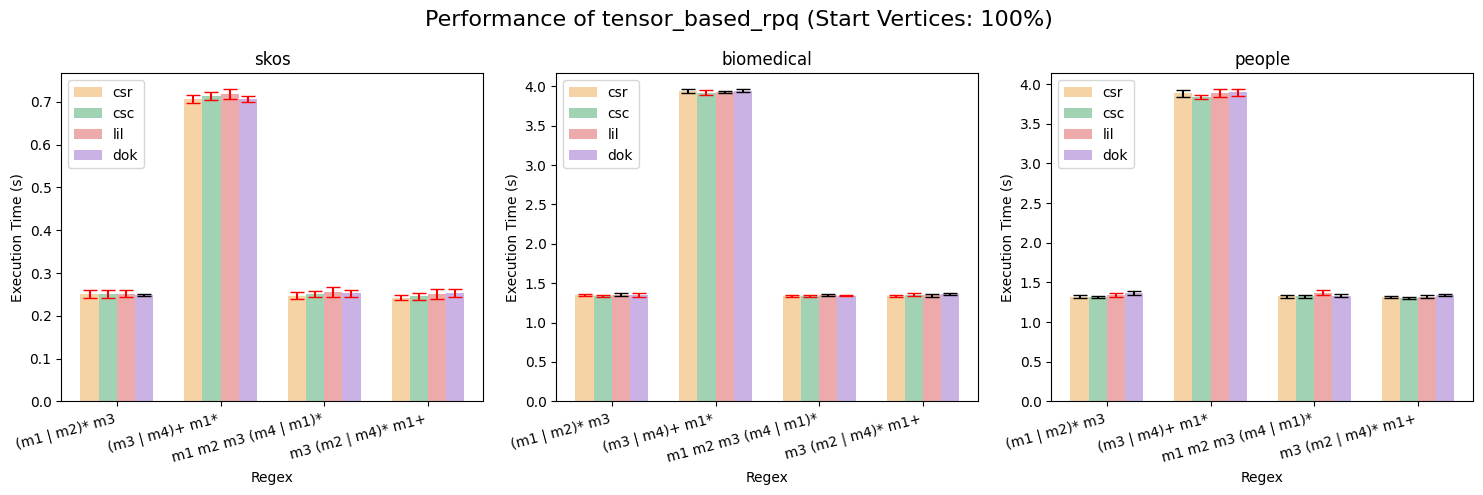

In [ ]:
run_matrix_type_experiment(tensor_based_rpq)

### Сравнение производительности и вывод для `tensor_based_rpq`
Для всех трёх графов и всех четырёх регулярных выражений наблюдается следующая картина:
 - `CSR` - наиболее быстрый формат.
 - `CSC` - практически идентичен `CSR` по времени, иногда чуть медленнее.
 - `LIL` - чаще всего медленнее.
 - `DOK` - также медленнее, чем `CSR`/`CSC`, но быстрее LIL.

#### Объяснение результатов
Алгоритм tensor_based_rpq включает построение тензорного произведения и возведение матрицы в степень, что требует эффективного умножения и сложения разреженных матриц, для чего не подходит `LIL`, при этом `CSR` обеспечивает более быстрый доступ по строкам, что необходимо при построении результата. Именно по этому он и лучше подходит.

#### О надёжности
Хотя в большинстве случаев распределение времени выполнения не является нормальным (флаг Normal=False), доверительные интервалы остаются узкими (<0.04 с), что говорит о стабильности замеров и что данный момент можно обосновать погрешностью.

### В виду того что алгоритм в `ms_bfs_based_rpq` основ на достижимости для заданного множества стартовых вершин, сделаем замеры для нескольких случаев

#### `ms_bfs_based_rpq` с 10% стартовых вершин

### Results for `skos`

,Regex,Matrix Type,Mean Time (s),Confidence Interval,Normal
0,(m1 | m2)* m3,csr,0.035,0.007,False
1,(m3 | m4)+ m1*,csr,0.037,0.008,False
2,m1 m2 m3 (m4 | m1)*,csr,0.039,0.007,False
3,m3 (m2 | m4)* m1+,csr,0.039,0.009,False
4,(m1 | m2)* m3,csc,0.039,0.009,False
5,(m3 | m4)+ m1*,csc,0.040,0.010,False
6,m1 m2 m3 (m4 | m1)*,csc,0.040,0.007,False
7,m3 (m2 | m4)* m1+,csc,0.037,0.006,False
8,(m1 | m2)* m3,lil,0.080,0.020,False
9,(m3 | m4)+ m1*,lil,0.080,0.010,False


### Results for `biomedical`

,Regex,Matrix Type,Mean Time (s),Confidence Interval,Normal
0,(m1 | m2)* m3,csr,0.070,0.010,False
1,(m3 | m4)+ m1*,csr,0.077,0.008,False
2,m1 m2 m3 (m4 | m1)*,csr,0.078,0.009,False
3,m3 (m2 | m4)* m1+,csr,0.093,0.009,False
4,(m1 | m2)* m3,csc,0.070,0.010,False
5,(m3 | m4)+ m1*,csc,0.080,0.010,False
6,m1 m2 m3 (m4 | m1)*,csc,0.080,0.010,False
7,m3 (m2 | m4)* m1+,csc,0.093,0.008,False
8,(m1 | m2)* m3,lil,0.220,0.020,True
9,(m3 | m4)+ m1*,lil,0.230,0.020,True


### Results for `people`

,Regex,Matrix Type,Mean Time (s),Confidence Interval,Normal
0,(m1 | m2)* m3,csr,0.100,0.020,False
1,(m3 | m4)+ m1*,csr,0.100,0.010,True
2,m1 m2 m3 (m4 | m1)*,csr,0.100,0.010,True
3,m3 (m2 | m4)* m1+,csr,0.090,0.010,False
4,(m1 | m2)* m3,csc,0.090,0.010,False
5,(m3 | m4)+ m1*,csc,0.100,0.010,True
6,m1 m2 m3 (m4 | m1)*,csc,0.100,0.010,False
7,m3 (m2 | m4)* m1+,csc,0.100,0.020,False
8,(m1 | m2)* m3,lil,0.260,0.010,False
9,(m3 | m4)+ m1*,lil,0.278,0.007,False


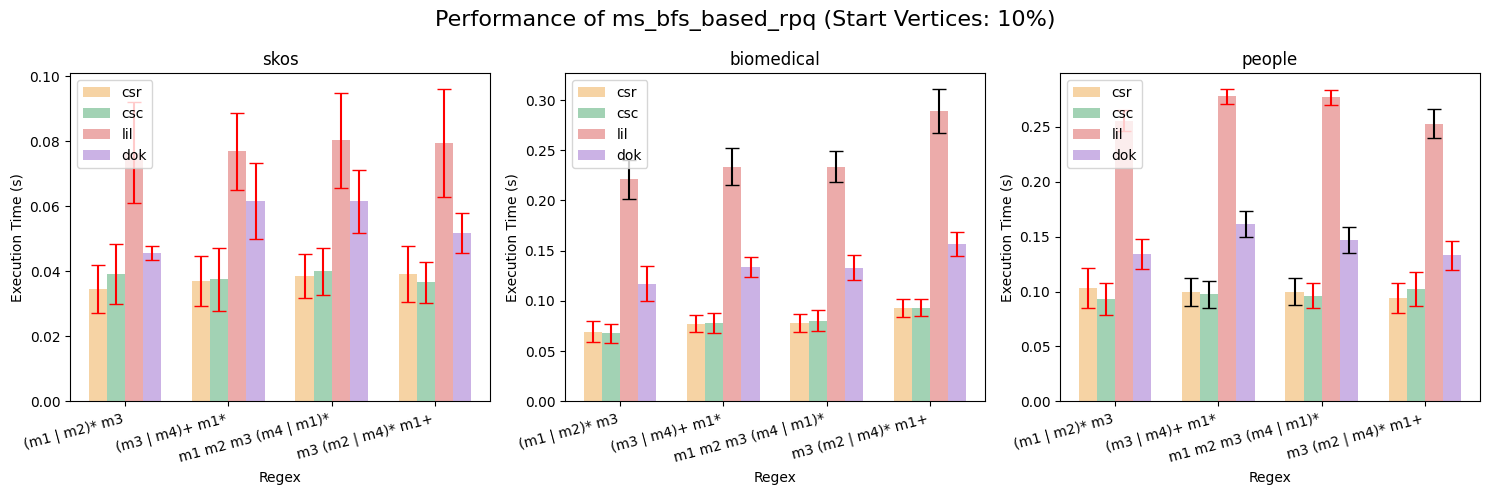

In [6]:
run_matrix_type_experiment(ms_bfs_based_rpq, 10)

#### `ms_bfs_based_rpq` с 100% стартовых вершин

### Results for `skos`

,Regex,Matrix Type,Mean Time (s),Confidence Interval,Normal
0,(m1 | m2)* m3,csr,0.209,0.008,False
1,(m3 | m4)+ m1*,csr,0.231,0.006,False
2,m1 m2 m3 (m4 | m1)*,csr,0.246,0.009,False
3,m3 (m2 | m4)* m1+,csr,0.252,0.009,False
4,(m1 | m2)* m3,csc,0.196,0.008,False
5,(m3 | m4)+ m1*,csc,0.221,0.009,False
6,m1 m2 m3 (m4 | m1)*,csc,0.240,0.006,False
7,m3 (m2 | m4)* m1+,csc,0.243,0.008,False
8,(m1 | m2)* m3,lil,0.450,0.020,False
9,(m3 | m4)+ m1*,lil,0.487,0.007,False


### Results for `biomedical`

,Regex,Matrix Type,Mean Time (s),Confidence Interval,Normal
0,(m1 | m2)* m3,csr,0.540,0.010,False
1,(m3 | m4)+ m1*,csr,0.610,0.020,False
2,m1 m2 m3 (m4 | m1)*,csr,0.640,0.010,False
3,m3 (m2 | m4)* m1+,csr,0.790,0.010,False
4,(m1 | m2)* m3,csc,0.520,0.010,False
5,(m3 | m4)+ m1*,csc,0.600,0.020,True
6,m1 m2 m3 (m4 | m1)*,csc,0.628,0.009,False
7,m3 (m2 | m4)* m1+,csc,0.760,0.010,False
8,(m1 | m2)* m3,lil,1.870,0.030,True
9,(m3 | m4)+ m1*,lil,2.080,0.040,True


### Results for `people`

,Regex,Matrix Type,Mean Time (s),Confidence Interval,Normal
0,(m1 | m2)* m3,csr,0.58,0.01,True
1,(m3 | m4)+ m1*,csr,0.71,0.02,True
2,m1 m2 m3 (m4 | m1)*,csr,0.70,0.01,True
3,m3 (m2 | m4)* m1+,csr,0.61,0.01,True
4,(m1 | m2)* m3,csc,0.56,0.01,True
5,(m3 | m4)+ m1*,csc,0.65,0.01,True
6,m1 m2 m3 (m4 | m1)*,csc,0.69,0.02,True
7,m3 (m2 | m4)* m1+,csc,0.59,0.01,True
8,(m1 | m2)* m3,lil,1.92,0.03,True
9,(m3 | m4)+ m1*,lil,2.39,0.05,True


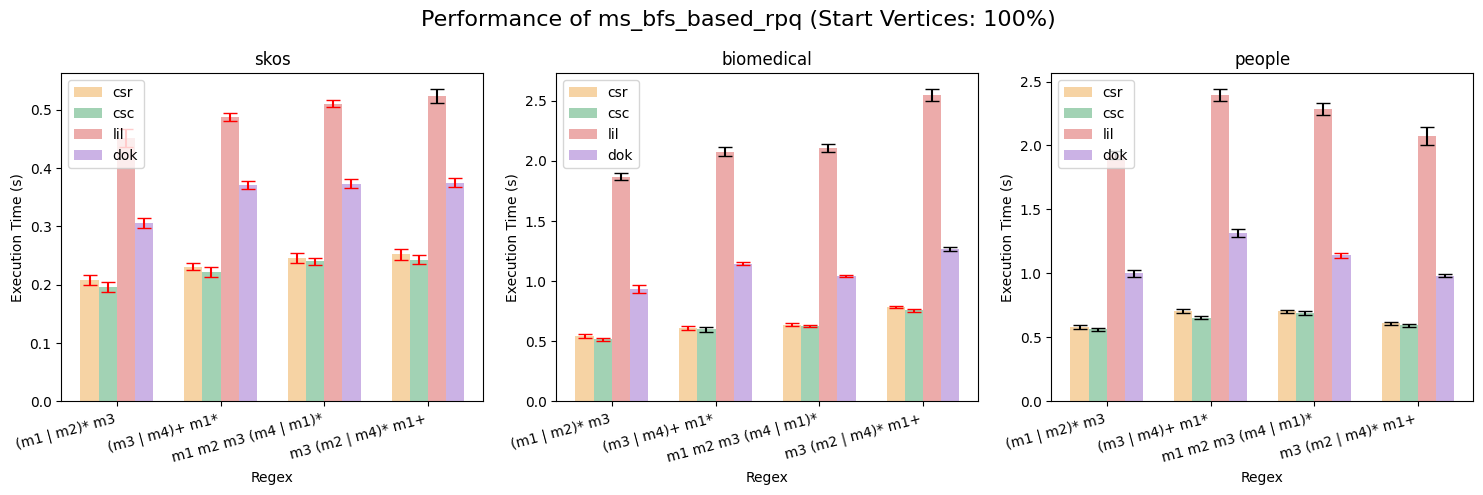

In [7]:
run_matrix_type_experiment(ms_bfs_based_rpq, 100)

### Сравнение производительности и вывод для `ms_bfs_based_rpq`
Для всех трёх графов и при обоих размерах стартового множества наблюдается следующая картина:
 - `CSC` - наиболее быстрый формат.
 - `CSR` - немного медленнее `CSC`, но часто сопоставим по времени.
 - `LIL` - значительно медленнее.
 - `DOK` - также медленнее, чем `CSR`/`CSC`.

#### Объяснение результатов
Про скорость арифметических операций `CSC` и `CSR` уже было сказано в объяснении результатов для `tensor_based_rpq`, попытаемся объяснить, почему `csc_array` чаще быстрее `csr_array`.

Транспонирование `CSC` даёт `CSR` (аналогично транспонирование `CSR` даёт `CSC`), поэтому центральная формула этого алгоритма - `CSR` @ `front` @ `CSC` (при исходном `CSC`) - является более сбалансированной по определению перемножения матриц.

#### О надежности
Аналогично результатам экспериментов для `tensor_based_rpq` доверительные интервалы остаются узкими (<0.02 с для экспериментов с 10% стартовыми вершинами и <0.07 с 100% стартовыми вершинами), что говорит о стабильности замеров.

## Вопрос №2. Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?

### Проведем замеры для `tensor_based_rpq` и `ms_bfs_based_rpq`, взяв за тип матрицы `csr_matrix`, как изначально было сделано в реализации алгоритмов

#### Замер для `(m1 | m2)* m3`:

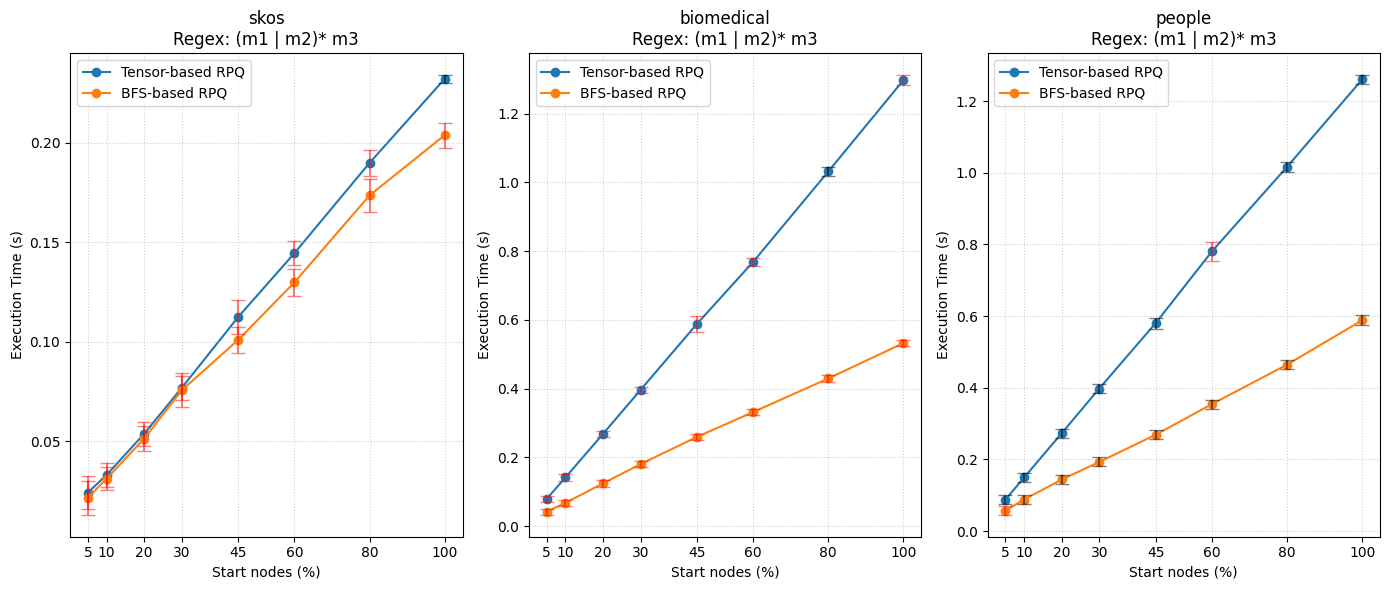

In [6]:
compare_rpq_methods(0)

#### Замер для `(m3 | m4)+ m1*`:

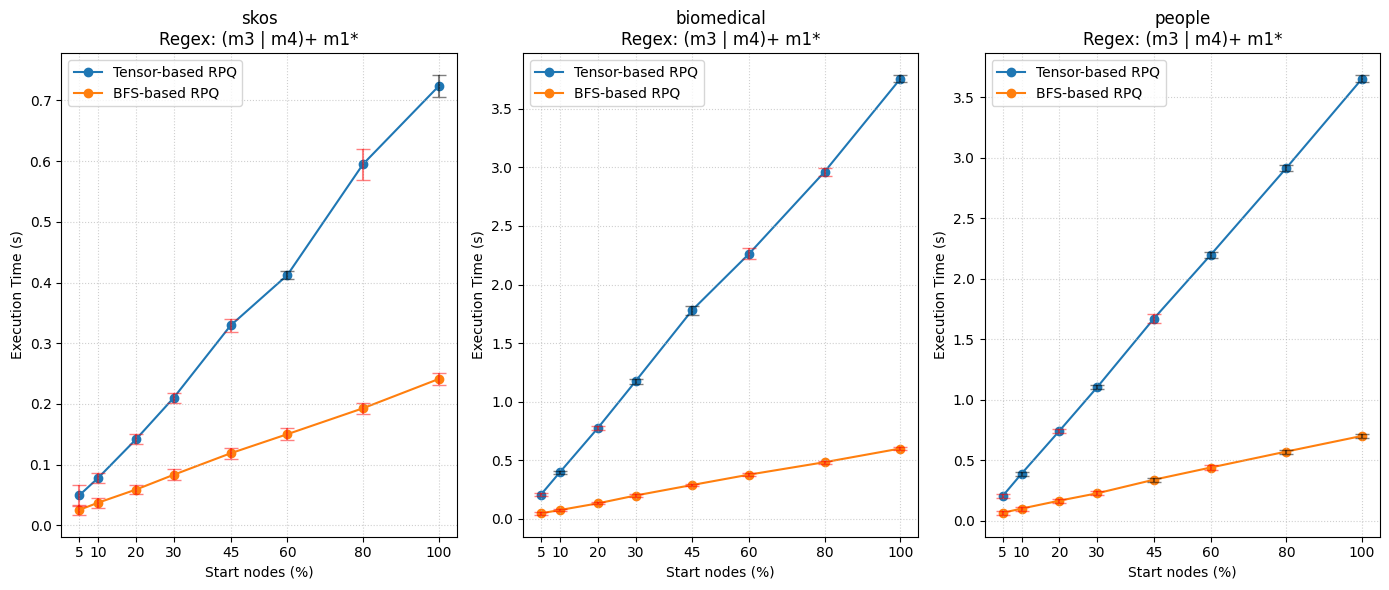

In [12]:
compare_rpq_methods(1)

#### Замер для `m1 m2 m3 (m4 | m1)*`:

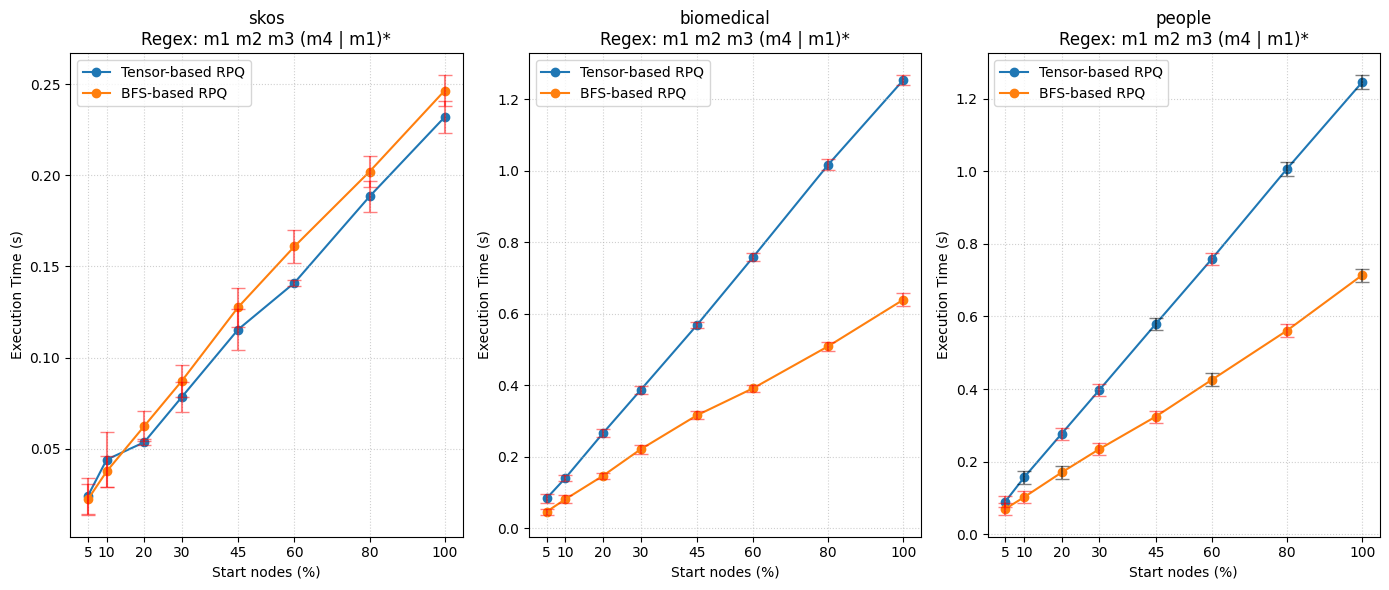

In [15]:
compare_rpq_methods(2)

#### Замер для `m3 (m2 | m4)* m1+`:

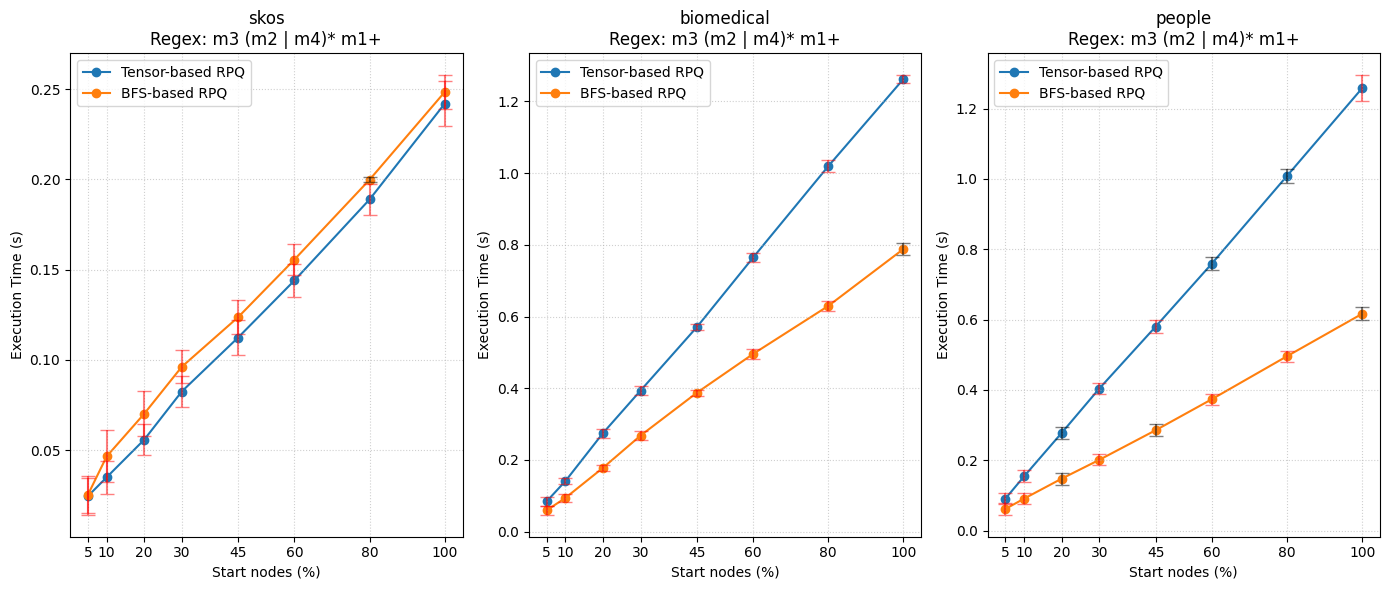

In [14]:
compare_rpq_methods(3)

### Вывод:
Для выбранных графов и регулярных выражений нет размера стартового множества, при котором `tensor_based_rpq` становится выгоднее `ms_bfs_based_rpq`.

#### Обоснование:
Данные показывают, что `ms_bfs_based_rpq` чаще всего быстрее, даже при 100% стартовых вершин.
Возможны 2 причины такого "странного" результата:
1) Малый размер графов (до 341 вершины), при котором фиксированная стоимость `tensor_based_rpq` превышает линейную стоимость `ms_bfs_based_rpq`, поэтому порог, при котором `tensor_based_rpq` становится выгоднее, не достигается в рамках эксперимента.
2) Неэффективной реализации для задачи "достижимости для каждой из заданного множества стартовых вершин": `tensor_based_rpq` выполняет квадратичный перебор по всем парам (старт, финал) для получения результата, в то время как `ms_bfs_based_rpq` только перечисляет реально достижимые вершины. При условии, что все вершины графа являются финальными, этот перебор становится главным узким местом `tensor_based_rpq`.